<a href="https://colab.research.google.com/github/mohamedelshiref135-collab/Employee-Attrition-Prediction/blob/main/My_Project_Employee_Attrion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [ ]:
data=pd.read_csv("/content/employee_churn_data.csv")

# EDA

In [ ]:
data.head()

,department,promoted,review,projects,salary,tenure,satisfaction,bonus,avg_hrs_month,left
0,operations,0,0.577569,3,low,5.0,0.626759,0,180.866070,no
1,operations,0,0.751900,3,medium,6.0,0.443679,0,182.708149,no
2,support,0,0.722548,3,medium,6.0,0.446823,0,184.416084,no
3,logistics,0,0.675158,4,high,8.0,0.440139,0,188.707545,no
4,sales,0,0.676203,3,high,5.0,0.577607,1,179.821083,no


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9540 entries, 0 to 9539
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   department     9540 non-null   object 
 1   promoted       9540 non-null   int64  
 2   review         9540 non-null   float64
 3   projects       9540 non-null   int64  
 4   salary         9540 non-null   object 
 5   tenure         9540 non-null   float64
 6   satisfaction   9540 non-null   float64
 7   bonus          9540 non-null   int64  
 8   avg_hrs_month  9540 non-null   float64
 9   left           9540 non-null   object 
dtypes: float64(4), int64(3), object(3)
memory usage: 745.4+ KB


In [ ]:
data.describe()

,promoted,review,projects,tenure,satisfaction,bonus,avg_hrs_month
count,9540.000000,9540.000000,9540.000000,9540.000000,9540.000000,9540.000000,9540.000000
mean,0.030294,0.651826,3.274843,6.556184,0.504645,0.212055,184.661571
std,0.171403,0.085307,0.579136,1.415432,0.158555,0.408785,4.144831
min,0.000000,0.310000,2.000000,2.000000,0.000000,0.000000,171.374060
25%,0.000000,0.592884,3.000000,5.000000,0.386801,0.000000,181.472085
50%,0.000000,0.647456,3.000000,7.000000,0.500786,0.000000,184.628796
75%,0.000000,0.708379,4.000000,8.000000,0.622607,0.000000,187.728708
max,1.000000,1.000000,5.000000,12.000000,1.000000,1.000000,200.861656


In [ ]:
data.duplicated().sum()

np.int64(0)

ANALYSIS


In [ ]:
left_salary=data[data["left"]=="yes"].groupby("salary").size()
left_salary

In [ ]:
left=data[data["left"]=="yes"].groupby("department").size()
left


In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=left.index, y=left.values, palette='viridis')
plt.title('Number of Employees Who Left by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees Left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
total_employees_per_department = data['department'].value_counts()


# Combine the two series into a single DataFrame
comparison_df = pd.DataFrame({
    'Total Employees': total_employees_per_department,
    'Employees Left': left,
    "Percentage":left/total_employees_per_department*100
}).fillna(0) # Fill NaN values with 0 if a department has no 'left' employees

# Ensure both are numeric types for plotting
comparison_df['Total Employees'] = comparison_df['Total Employees'].astype(int)
comparison_df['Employees Left'] = comparison_df['Employees Left'].astype(int)

display(comparison_df)

In [ ]:
average_salary_per_department = data.groupby('department')['salary'].mean().sort_values(ascending=False)

display(average_salary_per_department)

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=average_salary_per_department.index, y=average_salary_per_department.values, palette='plasma')
plt.title('Average Salary Level by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary Level (Encoded)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 10))
plt.pie(persinatge, labels=persinatge.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Employees Who Left by Department')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

In [ ]:
avg_hrs_by_left = data.groupby('left')['avg_hrs_month'].mean()

plt.figure(figsize=(8, 6))
sns.barplot(x=avg_hrs_by_left.index, y=avg_hrs_by_left.values, palette=['skyblue', 'salmon'])
plt.title('Average Monthly Hours for Employees Who Left vs. Stayed')
plt.xlabel('Employee Status (0=Stayed, 1=Left)')
plt.ylabel('Average Monthly Hours')
plt.xticks(ticks=[0, 1], labels=['Stayed (0)', 'Left (1)'])
plt.tight_layout()
plt.show()

In [ ]:
avg_review_by_left = data.groupby('left')['review'].mean()

plt.figure(figsize=(8, 6))
sns.barplot(x=avg_review_by_left.index, y=avg_review_by_left.values, palette=['lightgreen', 'lightcoral'])
plt.title('Average Review Score for Employees Who Left vs. Stayed')
plt.xlabel('Employee Status (0=Stayed, 1=Left)')
plt.ylabel('Average Review Score')
plt.xticks(ticks=[0, 1], labels=['Stayed (0)', 'Left (1)'])
plt.tight_layout()
plt.show()

In [ ]:
employees_left = data[data['left'] == 'yes'] # Filter for employees who left (where 'left' is 'yes')

plt.figure(figsize=(10, 8))
sns.scatterplot(x='review', y='satisfaction', data=employees_left, alpha=0.6, hue='left', legend=False)
plt.title('Review Score vs. Satisfaction for Employees Who Left')
plt.xlabel('Review Score')
plt.ylabel('Satisfaction Level')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(15, 7))
comparison_df.plot(kind='bar', figsize=(15, 7))
plt.title('Total Employees vs. Employees Who Left by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

In [ ]:
data2=data.copy()

In [ ]:
data2.head()

,department,promoted,review,projects,salary,tenure,satisfaction,bonus,avg_hrs_month,left
0,operations,0,0.577569,3,low,5.0,0.626759,0,180.866070,no
1,operations,0,0.751900,3,medium,6.0,0.443679,0,182.708149,no
2,support,0,0.722548,3,medium,6.0,0.446823,0,184.416084,no
3,logistics,0,0.675158,4,high,8.0,0.440139,0,188.707545,no
4,sales,0,0.676203,3,high,5.0,0.577607,1,179.821083,no


In [ ]:
data2['left'] = data2['left'].map({'no': 0, 'yes': 1})

In [ ]:
data2.info()

Text(0.5, 1.0, 'Correlation Heatmap')

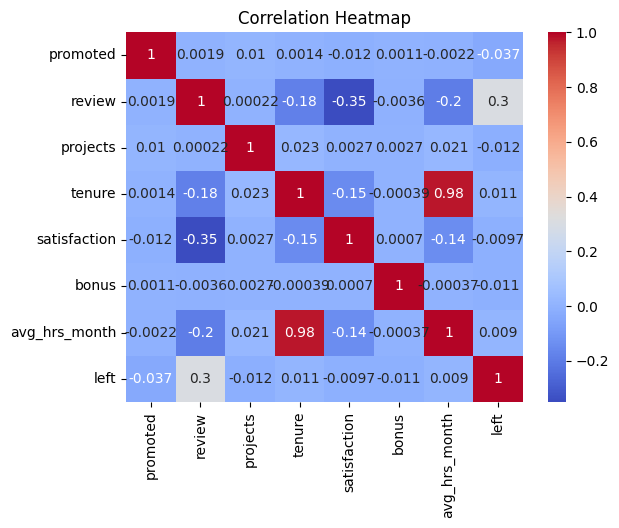

In [ ]:
sns.heatmap(data2.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data['avg_hrs_month_scaled'] = scaler.fit_transform(data[['avg_hrs_month']])

display(data[['avg_hrs_month', 'avg_hrs_month_scaled']].head())

,avg_hrs_month,avg_hrs_month_scaled
0,180.866070,0.321898
1,182.708149,0.384368
2,184.416084,0.442288
3,188.707545,0.587823
4,179.821083,0.286460


# DATA PREPROSSING

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
data['left'].value_counts()

,count
left,
no,6756
yes,2784


In [ ]:
data=data.drop(['promoted'],axis=1)

In [ ]:
salary_mapping = {'low': 0, 'medium': 1, 'high': 2}
data['salary'] = data['salary'].map(salary_mapping)

print(data['salary'].value_counts())
print(data.head())

salary
1    6611
2    1548
0    1381
Name: count, dtype: int64
   department    review  projects  salary  tenure  satisfaction  bonus  \
0  operations  0.577569         3       0     5.0      0.626759      0   
1  operations  0.751900         3       1     6.0      0.443679      0   
2     support  0.722548         3       1     6.0      0.446823      0   
3   logistics  0.675158         4       2     8.0      0.440139      0   
4       sales  0.676203         3       2     5.0      0.577607      1   

   avg_hrs_month left  
0     180.866070   no  
1     182.708149   no  
2     184.416084   no  
3     188.707545   no  
4     179.821083   no  


In [ ]:
data.head()

,department,review,projects,salary,tenure,satisfaction,bonus,avg_hrs_month,left
0,operations,0.577569,3,0,5.0,0.626759,0,180.866070,no
1,operations,0.751900,3,1,6.0,0.443679,0,182.708149,no
2,support,0.722548,3,1,6.0,0.446823,0,184.416084,no
3,logistics,0.675158,4,2,8.0,0.440139,0,188.707545,no
4,sales,0.676203,3,2,5.0,0.577607,1,179.821083,no


In [ ]:
data = pd.get_dummies(data, columns=['department'], drop_first=True)

In [ ]:
# target
data['left'] = data['left'].map({'no': 0, 'yes': 1})

In [ ]:
data.head()

,review,projects,salary,tenure,satisfaction,bonus,avg_hrs_month,left,department_admin,department_engineering,department_finance,department_logistics,department_marketing,department_operations,department_retail,department_sales,department_support
0,0.577569,3,0,5.0,0.626759,0,180.866070,0,False,False,False,False,False,True,False,False,False
1,0.751900,3,1,6.0,0.443679,0,182.708149,0,False,False,False,False,False,True,False,False,False
2,0.722548,3,1,6.0,0.446823,0,184.416084,0,False,False,False,False,False,False,False,False,True
3,0.675158,4,2,8.0,0.440139,0,188.707545,0,False,False,False,True,False,False,False,False,False
4,0.676203,3,2,5.0,0.577607,1,179.821083,0,False,False,False,False,False,False,False,True,False


In [ ]:
data.columns

Index(['review', 'projects', 'salary', 'tenure', 'satisfaction', 'bonus',
       'avg_hrs_month', 'left', 'department_admin', 'department_engineering',
       'department_finance', 'department_logistics', 'department_marketing',
       'department_operations', 'department_retail', 'department_sales',
       'department_support'],
      dtype='object')

In [ ]:
X = data.drop(columns=["left"], axis=1)
Y = data["left"]

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.1, stratify=Y, random_state=1)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(9540, 16) (8586, 16) (954, 16)


# MAKE ML MODEL
get best model


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, recall_score,precision_score, f1_score

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

from collections import Counter

plt.style.use('fivethirtyeight')

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
model1=LogisticRegression()
model2=SVC()
model3=RandomForestClassifier(max_depth= None, min_samples_leaf= 1, min_samples_split= 2, n_estimators= 500)
model4=GradientBoostingClassifier(n_estimators=1000)
model5=KNeighborsClassifier()
model6=GaussianNB()
model7=DecisionTreeClassifier()

In [ ]:
col=['LogisticRegression','SVC','RandomForestClassifier','GradientBoostingClassifier','KNeighborsClassifier','GaussianNB','DecisionTreeClassifier']
result1=[]
result2=[]
result3=[]
result4=[]

LogisticRegression()
accuracy is :  0.7232704402515723 recall is : 0.6590909090909091 precision is : 0.10431654676258993 f1 is : 0.18012422360248448


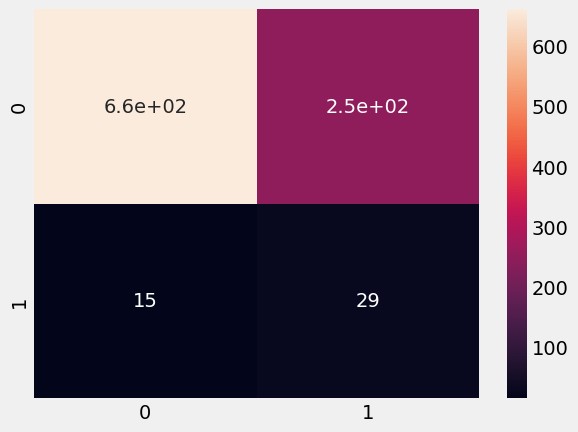

In [ ]:
def cal(model, X_train_data=None, Y_train_data=None, X_test_data=None, Y_test_data=None):
    if X_train_data is None:
        X_train_data = X_train
    if Y_train_data is None:
        Y_train_data = Y_train
    if X_test_data is None:
        X_test_data = X_test
    if Y_test_data is None:
        Y_test_data = Y_test

    model.fit(X_train_data, Y_train_data)
    pre=model.predict(X_test_data)
    accuracy=accuracy_score(pre,Y_test_data)
    recall=recall_score(pre,Y_test_data)
    precision=precision_score(pre,Y_test_data)
    f1=f1_score(pre,Y_test_data)

    result1.append(accuracy)
    result2.append(recall)
    result3.append(precision)
    result4.append(f1)

    sns.heatmap(confusion_matrix(pre,Y_test_data),annot=True)
    print(model)
    print('accuracy is : ',accuracy,'recall is :',recall,'precision is :',precision,'f1 is :' ,f1)
cal(model1)

SVC()
accuracy is :  0.7085953878406709 recall is : 0.0 precision is : 0.0 f1 is : 0.0


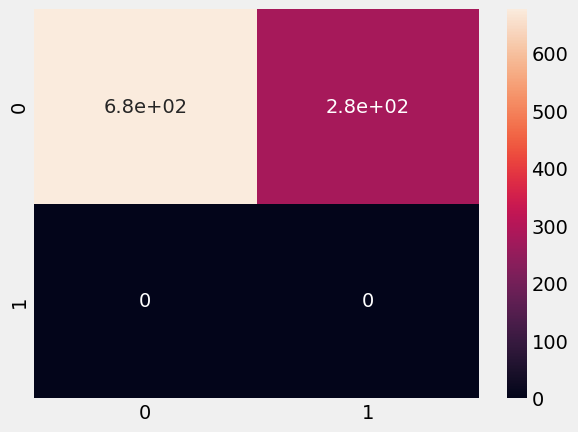

In [ ]:
cal(model2)

RandomForestClassifier(n_estimators=500)
accuracy is :  0.8522012578616353 recall is : 0.7914893617021277 precision is : 0.6690647482014388 f1 is : 0.7251461988304093


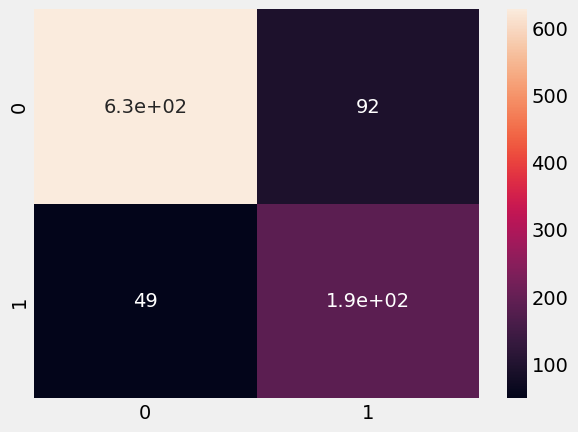

In [ ]:
cal(model3)

GradientBoostingClassifier(n_estimators=1000)
accuracy is :  0.8469601677148847 recall is : 0.7519083969465649 precision is : 0.7086330935251799 f1 is : 0.7296296296296296


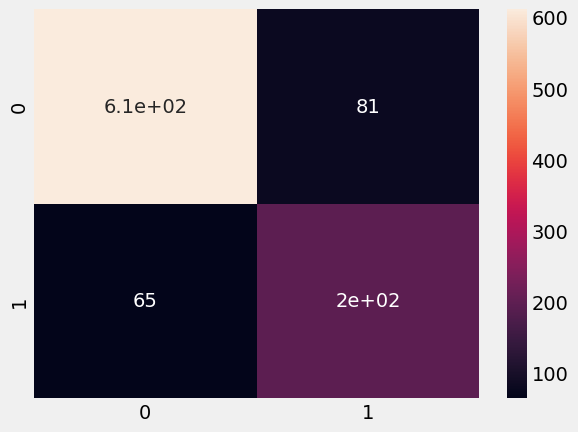

In [ ]:
cal(model4)

GradientBoostingClassifier(n_estimators=1000)
accuracy is :  0.8480083857442348 recall is : 0.752851711026616 precision is : 0.7122302158273381 f1 is : 0.7319778188539742


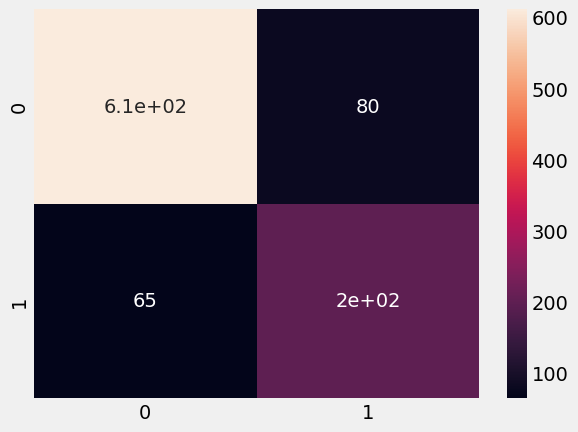

In [ ]:
cal(model4)

KNeighborsClassifier()
accuracy is :  0.740041928721174 recall is : 0.5728155339805825 precision is : 0.4244604316546763 f1 is : 0.48760330578512395


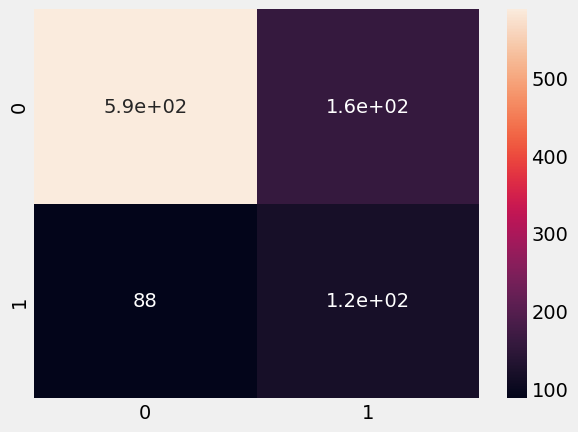

In [ ]:
cal(model5)

GaussianNB()
accuracy is :  0.7274633123689728 recall is : 0.5818181818181818 precision is : 0.2302158273381295 f1 is : 0.32989690721649484


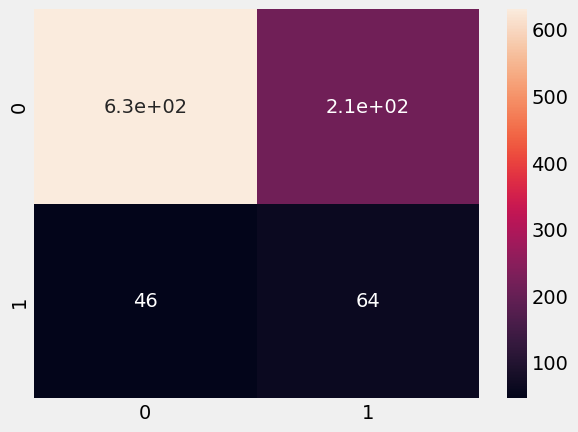

In [ ]:
cal(model6)

DecisionTreeClassifier()
accuracy is :  0.8207547169811321 recall is : 0.6903914590747331 precision is : 0.697841726618705 f1 is : 0.6940966010733453


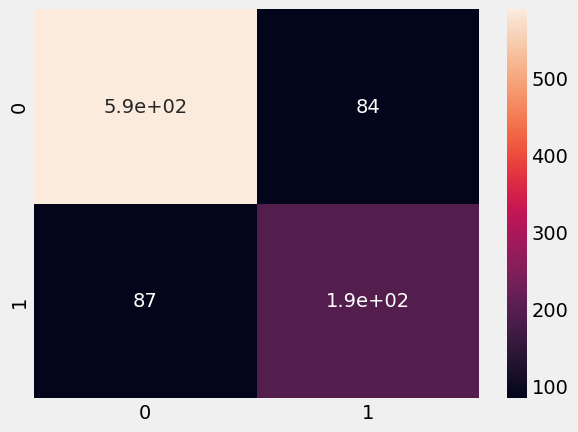

In [ ]:
cal(model7)

In [ ]:
final_result=pd.DataFrame({'Algorisms':col , 'Accuracies':result1[:len(col)],'Recal':result2[:len(col)],'precision':result3[:len(col)],'F1_Score':result4[:len(col)]})

In [ ]:
final_result

,Algorisms,Accuracies,Recal,precision,F1_Score
0,LogisticRegression,0.723270,0.659091,0.104317,0.180124
1,SVC,0.708595,0.000000,0.000000,0.000000
2,RandomForestClassifier,0.852201,0.791489,0.669065,0.725146
3,GradientBoostingClassifier,0.846960,0.751908,0.708633,0.729630
4,KNeighborsClassifier,0.848008,0.752852,0.712230,0.731978
5,GaussianNB,0.740042,0.572816,0.424460,0.487603
6,DecisionTreeClassifier,0.727463,0.581818,0.230216,0.329897


In [ ]:
# # تحديد الأعمدة الرقمية
# numerical_cols = data.select_dtypes(include=np.number).columns

# # رسم Boxplot لكل عمود رقمي
# plt.figure(figsize=(15, 10))
# for i, col in enumerate(numerical_cols):
#     plt.subplot(len(numerical_cols) // 3 + 1, 3, i + 1) # ترتيب الرسوم في شبكة
#     sns.boxplot(y=data[col])
#     plt.title(f'Boxplot of {col}')
#     plt.ylabel('') # إزالة تسمية المحور y الافتراضية
# plt.tight_layout()
# plt.show()

### Building a Machine Learning Pipeline with RandomForest

In [ ]:



data_pipeline = pd.read_csv("/content/employee_churn_data.csv")

# Drop 'promoted' as decided earlier in the notebook
data_pipeline = data_pipeline.drop(['promoted'], axis=1)

# Map the target variable 'left' to numerical
data_pipeline['left'] = data_pipeline['left'].map({'no': 0, 'yes': 1})

# Define features (X) and target (y)
X_pipeline = data_pipeline.drop('left', axis=1)
y_pipeline = data_pipeline['left']

# Define feature types for preprocessing
categorical_features = ['department']
ordinal_features = ['salary']
numerical_features = ['review', 'projects', 'tenure', 'satisfaction', 'bonus', 'avg_hrs_month']

# Create preprocessing steps
numerical_transformer = StandardScaler() # Standardize numerical features
categorical_transformer = OneHotEncoder(handle_unknown='ignore') # One-hot encode categorical features

# Define the order for ordinal encoding of 'salary' to ensure correct mapping
salary_categories = ['low', 'medium', 'high']
ordinal_transformer = OrdinalEncoder(categories=[salary_categories])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
        ('ord', ordinal_transformer, ordinal_features)
    ])

# Create the full pipeline: preprocessor + RandomForestClassifier
# Using the best parameters found earlier for RandomForest
random_forest_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                         ('classifier', RandomForestClassifier(max_depth=None,
                                                                               max_features='sqrt',
                                                                               min_samples_leaf=3,
                                                                               min_samples_split=4,
                                                                               n_estimators=745,
                                                                               random_state=42))])


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['review', 'projects',
                                                   'tenure', 'satisfaction',
                                                   'bonus', 'avg_hrs_month']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['department']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high']]),
                                                  ['salary'])])),
                ('classifier',
                 RandomForestClas

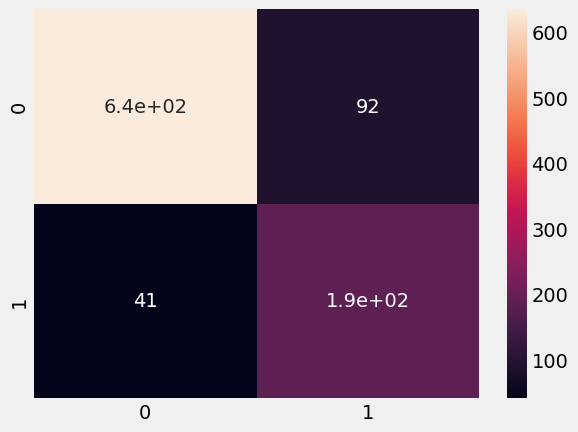

In [ ]:
X_train_pipeline, X_test_pipeline, y_train_pipeline, y_test_pipeline = train_test_split(
    X_pipeline, y_pipeline, test_size=0.1, stratify=y_pipeline, random_state=1)
cal(random_forest_pipeline,X_train_pipeline,y_train_pipeline, X_test_pipeline,y_test_pipeline)

# save the data

In [ ]:
import pickle

In [ ]:
filename="/content/employee_churn_data.sav"
pickle.dump(random_forest_pipeline,open(filename,'wb'))

In [ ]:
from google.colab import files
files.download("/content/employee_churn_data.sav")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1
